In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     345   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [4]:
image_cut = image[77:177, 0:1890]
image_error_cut = image_error[77:177, 0:1890]

Text(0.5, 0, 'wavelength')

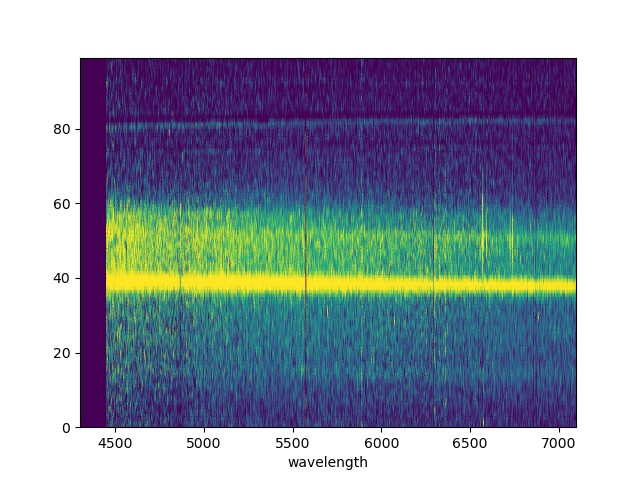

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 52*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax=np.percentile(image_cut, 95))
plt.xlabel('wavelength')

In [6]:
z = 0.00189
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/PSF/Real_seeing_UGC7596.txt")
sigma = seeing[0]/2.35

In [7]:
l_HA

6575.40407

Text(0.5, 1.0, 'H$\\alpha$')

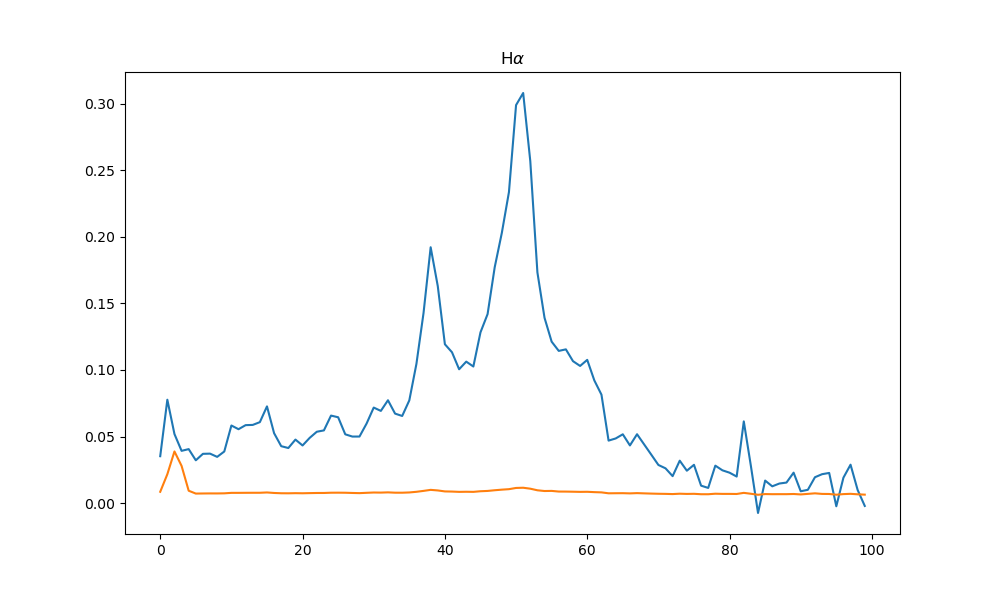

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [17]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
def chi_quad(x, y, y_err, params):
    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, y_err, params): #k=number of model parameter, N=number of data points
    return chi_quad(x, y, y_err, params) + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, y_err, params):
        return chi_quad(x, y, y_err, params) + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (14, 20),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 38.44233872821323
differential_evolution step 2: f(x)= 33.74117343477508
differential_evolution step 3: f(x)= 27.297822282374888
differential_evolution step 4: f(x)= 20.58396646010648
differential_evolution step 5: f(x)= 20.58396646010648
differential_evolution step 6: f(x)= 18.532932635969082
differential_evolution step 7: f(x)= 18.373675462745208
differential_evolution step 8: f(x)= 18.373675462745208
differential_evolution step 9: f(x)= 17.797277516494695
differential_evolution step 10: f(x)= 17.797277516494695
differential_evolution step 11: f(x)= 17.797277516494695
differential_evolution step 12: f(x)= 17.78713621223433
differential_evolution step 13: f(x)= 17.198996548645304
differential_evolution step 14: f(x)= 16.990552787893964
differential_evolution step 15: f(x)= 16.42375905805395
differential_evolution step 16: f(x)= 16.42375905805395
differential_evolution step 17: f(x)= 16.42375905805395
differential_evolution step 18: f(x)= 16.4237590

141052.44105115245 141044.0932250655 141063.24319203664 4
Reduced chi square: 1215.8973553884957


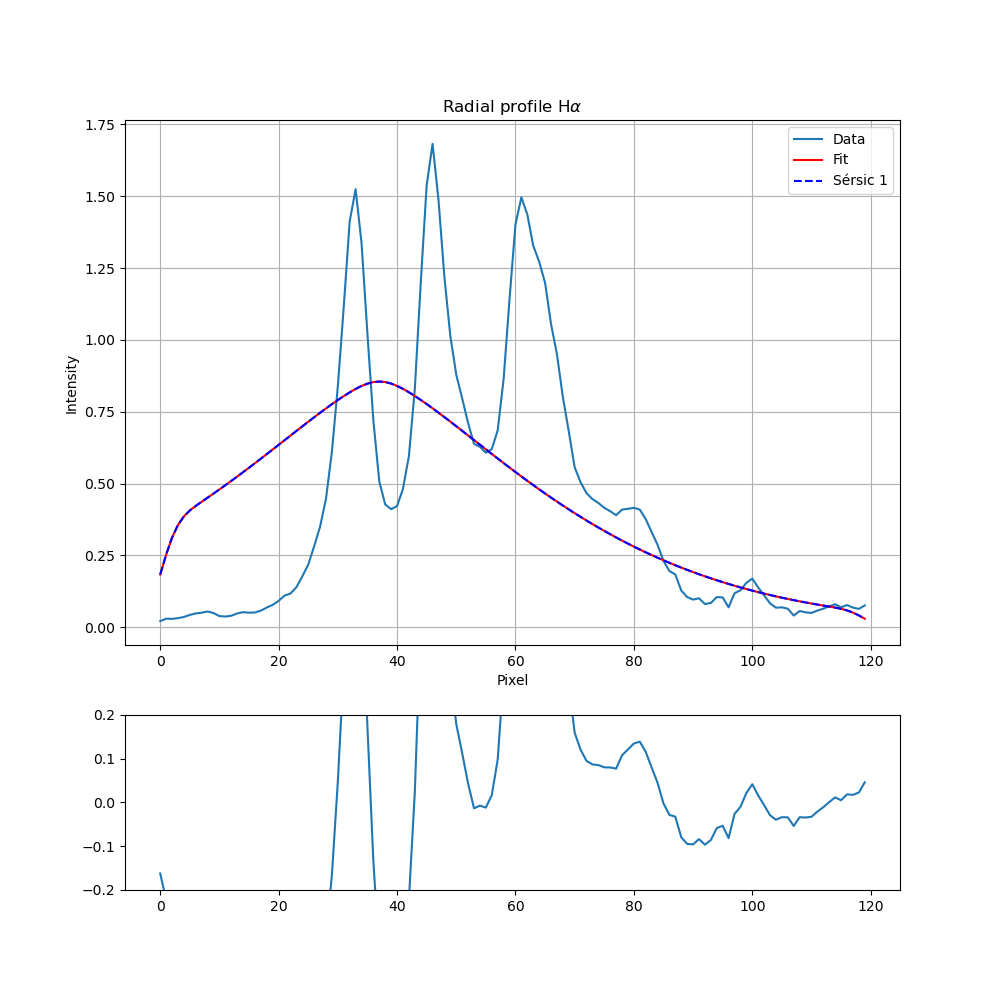

In [19]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *best_params1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic = np.zeros(6)
bic = np.zeros(6)
chi_quadr = np.zeros(6)
red_chi = np.zeros(6)
aic[0] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params1)
chi_quadr[0] = chi_quad(x_axes, radial_profile_HA, radial_profile_error_HA, best_params1)
bic[0] = BIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params1)
print(aic[0], chi_quadr[0], bic[0], len(best_params1))

dof_HA = len(radial_profile_HA) - len(best_params1)
print('Reduced chi square:', chi_quadr[0] / dof_HA)
red_chi[0] = chi_quadr[0] / dof_HA
plt.savefig('AIC_1')

In [ ]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (14, 20)   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 156.996319337766
differential_evolution step 2: f(x)= 156.996319337766
differential_evolution step 3: f(x)= 44.70933161788045
differential_evolution step 4: f(x)= 28.18919618689065
differential_evolution step 5: f(x)= 28.18919618689065
differential_evolution step 6: f(x)= 16.53365650258749
differential_evolution step 7: f(x)= 16.53365650258749
differential_evolution step 8: f(x)= 16.53365650258749
differential_evolution step 9: f(x)= 16.53365650258749
differential_evolution step 10: f(x)= 9.795852506044412
differential_evolution step 11: f(x)= 9.795852506044412
differential_evolution step 12: f(x)= 9.697873625833585
differential_evolution step 13: f(x)= 9.697873625833585
differential_evolution step 14: f(x)= 9.697873625833585
differential_evolution step 15: f(x)= 9.697873625833585
differential_evolution step 16: f(x)= 9.697873625833585
differential_evolution step 17: f(x)= 9.697873625833585
differential_evolution step 18: f(x)= 9.666765206262252
dif

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *best_params2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[1] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params2)
chi_quadr[1] = chi_quad(x_axes, radial_profile_HA, radial_profile_error_HA, best_params2)
bic[1] = BIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params2)
print(aic[1], chi_quadr[1], bic[1], len(best_params2))

dof_HA = len(radial_profile_HA) - len(best_params2)
print('Reduced chi square:', chi_quadr[1] / dof_HA)
red_chi[1] = chi_quadr[1] / dof_HA
plt.savefig('AIC_2')

In [ ]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (14, 20)   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (28, 36)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *best_params3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[2] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params3)
chi_quadr[2] = chi_quad(x_axes, radial_profile_HA, radial_profile_error_HA, best_params3)
bic[2] = BIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params3)
print(aic[2], chi_quadr[2], bic[2], len(best_params3))

dof_HA = len(radial_profile_HA) - len(best_params3)
print('Reduced chi square:', chi_quadr[2] / dof_HA)
red_chi[2] = chi_quadr[2] / dof_HA
plt.savefig('AIC_3')

In [ ]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (14, 20)   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (28, 36),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (67, 74),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *best_params4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[3] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params4)
chi_quadr[3] = chi_quad(x_axes, radial_profile_HA, radial_profile_error_HA, best_params4)
bic[3] = BIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params4)
print(aic[3], chi_quadr[3], bic[3], len(best_params4))

dof_HA = len(radial_profile_HA) - len(best_params4)
print('Reduced chi square:', chi_quadr[3] / dof_HA)
red_chi[3] = chi_quadr[3] / dof_HA
plt.savefig('AIC_4')

In [ ]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (14, 20)   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (28, 36),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (67, 74),     # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *best_params5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[4] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params5)
chi_quadr[4] = chi_quad(x_axes, radial_profile_HA, radial_profile_error_HA, best_params5)
bic[4] = BIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params5)
print(aic[4], chi_quadr[4], bic[4], len(best_params5))

dof_HA = len(radial_profile_HA) - len(best_params5)
print('Reduced chi square:', chi_quadr[4] / dof_HA)
red_chi[4] = chi_quadr[4] / dof_HA
plt.savefig('AIC_5')

In [ ]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
   (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (14, 20)   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (18, 23),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (28, 36),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (67, 74),     # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *best_params6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[5] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params6)
chi_quadr[5] = chi_quad(x_axes, radial_profile_HA, radial_profile_error_HA, best_params6)
bic[5] = BIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

dof_HA = len(radial_profile_HA) - len(best_params6)
print('Reduced chi square:', chi_quadr[5] / dof_HA)
red_chi[5] = chi_quadr[5] / dof_HA
plt.savefig('AIC_6')

In [ ]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N')

In [ ]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log')